# N-gram and Collocation Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 5**

This notebook analyzes multi-word expressions and collocations in Kazakhstan's legal codes:
- Bigram and trigram extraction
- Legal phrase patterns
- Domain-specific terminology
- Cross-code phrase comparison

## 1. Setup and Imports

In [13]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# NLP
import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 100

nlp = spacy.load("ru_core_news_sm")
print("Setup complete!")

Setup complete!


## 2. Data Loading

In [14]:
# Define codes (using historical data - latest versions)
CODES = {
    "criminal": {"history_folder": "K1400000226_rus_ugolov", "name_en": "Criminal Code", "short": "УК"},
    "administrative": {"history_folder": "K1400000235_rus_adm", "name_en": "Administrative Code", "short": "КоАП"},
    "civil": {"history_folder": "K940001000__rus_grazh", "name_en": "Civil Code", "short": "ГК"},
    "labor": {"history_folder": "K1500000414_rus_trud", "name_en": "Labor Code", "short": "ТК"},
    "tax": {"history_folder": "K2500000214_rus_nalog", "name_en": "Tax Code", "short": "НК"}
}

DATA_PATH = Path("../data/raw/by_history")

def load_latest_version(code_key):
    """Load the latest version of a legal code from historical data."""
    folder_path = DATA_PATH / CODES[code_key]["history_folder"]
    index_path = folder_path / "versions_index.json"
    
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    latest_version = index["versions"][-1]
    version_file = folder_path / latest_version["filename"]
    
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    return data["articles"]

# Load all codes
codes_data = {}
for code_key in CODES:
    codes_data[code_key] = load_latest_version(code_key)
    print(f"{CODES[code_key]['short']}: {len(codes_data[code_key])} articles")

УК: 502 articles
КоАП: 1066 articles
ГК: 425 articles
ТК: 221 articles
НК: 848 articles


## 3. N-gram Extraction

In [17]:
def preprocess_for_ngrams(text):
    """Preprocess text preserving word order for n-gram analysis."""
    doc = nlp(text.lower())
    tokens = [
        t.lemma_ for t in doc 
        if not t.is_punct and not t.is_space
        and len(t.text) > 1 and t.is_alpha
    ]
    return " ".join(tokens)

def extract_ngrams(documents, n=2, top_k=50):
    """Extract top n-grams from documents."""
    vectorizer = CountVectorizer(
        ngram_range=(n, n),
        max_features=1000,
        min_df=2
    )
    
    try:
        dtm = vectorizer.fit_transform(documents)
        feature_names = vectorizer.get_feature_names_out()
        
        # Sum frequencies
        freqs = dtm.sum(axis=0).A1
        ngram_freq = list(zip(feature_names, freqs))
        ngram_freq.sort(key=lambda x: x[1], reverse=True)
        
        return ngram_freq[:top_k]
    except:
        return []

# Preprocess all documents
print("Preprocessing for n-gram analysis...")
preprocessed_docs = {}

for code_key in CODES:
    docs = []
    for article in codes_data[code_key]:
        text = article.get("article_text", "")
        if text:
            processed = preprocess_for_ngrams(text)
            if len(processed.split()) > 5:
                docs.append(processed)
    preprocessed_docs[code_key] = docs
    print(f"  {CODES[code_key]['short']}: {len(docs)} documents")

Preprocessing for n-gram analysis...
  УК: 489 documents
  КоАП: 1009 documents
  ГК: 415 documents
  ТК: 218 documents
  НК: 847 documents


In [18]:
# Extract bigrams
print("\nExtracting bigrams...")
bigrams = {}

for code_key in CODES:
    docs = preprocessed_docs[code_key]
    bg = extract_ngrams(docs, n=2, top_k=30)
    bigrams[code_key] = bg
    
    print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}) - Top 10 bigrams:")
    for phrase, freq in bg[:10]:
        print(f"  {phrase}: {int(freq)}")


Extracting bigrams...

Criminal Code (УК) - Top 10 bigrams:
  на срок: 1791
  свобода на: 1328
  срок до: 1316
  тот же: 1129
  лишение свобода: 1093
  месячный расчётный: 611
  расчётный показатель: 611
  наказываться штраф: 512
  исправительный работа: 510
  штраф размер: 509

Administrative Code (КоАП) - Top 10 bigrams:
  на субъект: 2165
  предпринимательство размер: 1946
  расчётный показатель: 1826
  месячный расчётный: 1825
  влечь штраф: 1699
  республика казахстан: 1320
  штраф на: 1197
  административный правонарушение: 1051
  должностной лицо: 974
  лицо размер: 947

Civil Code (ГК) - Top 10 bigrams:
  законодательный акт: 326
  республика казахстан: 325
  юридический лицо: 299
  мочь быть: 219
  настоящий кодекс: 216
  иное не: 144
  если иное: 139
  не предусмотреть: 129
  акт республика: 105
  предусмотреть законодательный: 99

Labor Code (ТК) - Top 10 bigrams:
  республика казахстан: 331
  трудовой договор: 282
  настоящий кодекс: 171
  охрана труд: 145
  заработный пла

In [19]:
# Extract trigrams
print("\nExtracting trigrams...")
trigrams = {}

for code_key in CODES:
    docs = preprocessed_docs[code_key]
    tg = extract_ngrams(docs, n=3, top_k=20)
    trigrams[code_key] = tg
    
    print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}) - Top 10 trigrams:")
    for phrase, freq in tg[:10]:
        print(f"  {phrase}: {int(freq)}")


Extracting trigrams...

Criminal Code (УК) - Top 10 trigrams:
  на срок до: 1315
  лишение свобода на: 906
  свобода на срок: 901
  месячный расчётный показатель: 611
  наказываться штраф размер: 508
  расчётный показатель либо: 501
  исправительный работа тот: 478
  либо исправительный работа: 478
  показатель либо исправительный: 478
  работа тот же: 478

Administrative Code (КоАП) - Top 10 trigrams:
  месячный расчётный показатель: 1825
  влечь штраф на: 1122
  субъект крупный предпринимательство: 837
  на субъект крупный: 821
  на субъект средний: 812
  субъект средний предпринимательство: 811
  средний предпринимательство размер: 803
  крупный предпринимательство размер: 790
  субъект малый предпринимательство: 760
  об административный правонарушение: 705

Civil Code (ГК) - Top 10 trigrams:
  если иное не: 137
  акт республика казахстан: 105
  законодательный акт республика: 103
  предусмотреть законодательный акт: 99
  статья настоящий кодекс: 99
  иное не предусмотреть: 96
  з

## 4. Bigram Visualization

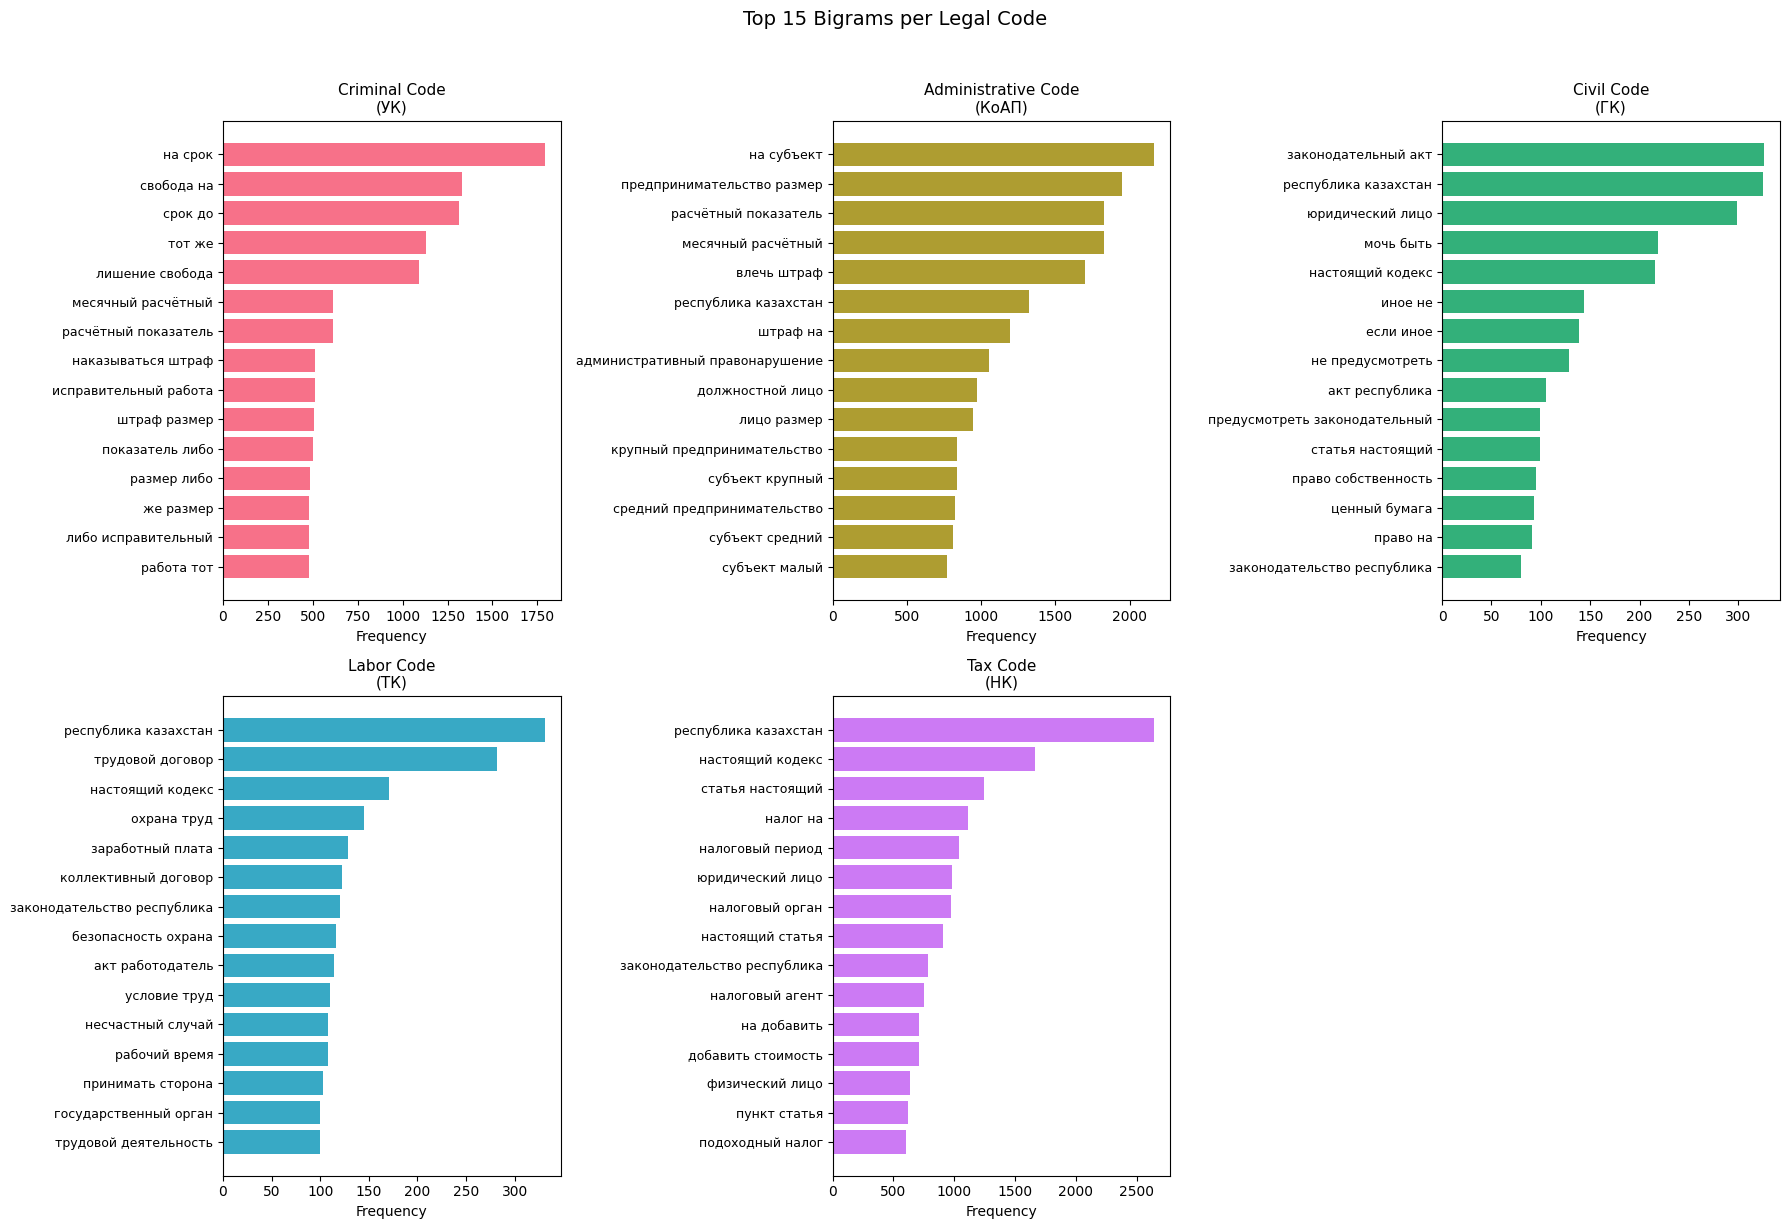

In [20]:
# Visualize top bigrams per code
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = sns.color_palette("husl", len(CODES))

for idx, code_key in enumerate(CODES):
    ax = axes[idx]
    bg = bigrams[code_key][:15]
    
    if bg:
        phrases, freqs = zip(*bg)
        y_pos = range(len(phrases))
        
        ax.barh(y_pos, freqs, color=colors[idx])
        ax.set_yticks(y_pos)
        ax.set_yticklabels(phrases, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Frequency")
        ax.set_title(f"{CODES[code_key]['name_en']}\n({CODES[code_key]['short']})", fontsize=11)

axes[-1].axis('off')

plt.suptitle("Top 15 Bigrams per Legal Code", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../output/05/bigrams_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Code Phrase Comparison

In [21]:
# Find shared and unique bigrams
from collections import defaultdict

bigram_to_codes = defaultdict(list)

for code_key in CODES:
    for phrase, freq in bigrams[code_key]:
        bigram_to_codes[phrase].append((CODES[code_key]["short"], freq))

# Shared bigrams (in 3+ codes)
shared_bigrams = {k: v for k, v in bigram_to_codes.items() if len(v) >= 3}

print(f"Bigrams appearing in 3+ codes: {len(shared_bigrams)}")
print("\nShared legal phrases:")
for phrase, codes in sorted(shared_bigrams.items(), key=lambda x: sum(f for _, f in x[1]), reverse=True)[:15]:
    code_list = [f"{c}({int(f)})" for c, f in codes]
    print(f"  {phrase}: {', '.join(code_list)}")

Bigrams appearing in 3+ codes: 5

Shared legal phrases:
  республика казахстан: КоАП(1320), ГК(325), ТК(331), НК(2645)
  настоящий кодекс: КоАП(512), ГК(216), ТК(171), НК(1667)
  статья настоящий: ГК(99), ТК(61), НК(1245)
  юридический лицо: ГК(299), ТК(83), НК(979)
  законодательство республика: ГК(80), ТК(120), НК(782)


In [22]:
# Find unique bigrams per code
print("\nUnique bigrams per code (not in any other code):")
print("="*60)

unique_bigrams = {}

for code_key in CODES:
    code_phrases = set(phrase for phrase, _ in bigrams[code_key])
    other_phrases = set()
    for k, bg in bigrams.items():
        if k != code_key:
            other_phrases.update(phrase for phrase, _ in bg)
    
    unique = code_phrases - other_phrases
    unique_bigrams[code_key] = unique
    
    # Get frequencies for unique bigrams
    unique_with_freq = [(p, f) for p, f in bigrams[code_key] if p in unique][:10]
    
    print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}) - {len(unique)} unique:")
    for phrase, freq in unique_with_freq:
        print(f"  {phrase}: {int(freq)}")


Unique bigrams per code (not in any other code):

Criminal Code (УК) - 27 unique:
  на срок: 1791
  свобода на: 1328
  срок до: 1316
  тот же: 1129
  лишение свобода: 1093
  наказываться штраф: 512
  исправительный работа: 510
  показатель либо: 501
  размер либо: 482
  же размер: 478

Administrative Code (КоАП) - 23 unique:
  на субъект: 2165
  предпринимательство размер: 1946
  влечь штраф: 1699
  штраф на: 1197
  административный правонарушение: 1051
  должностной лицо: 974
  лицо размер: 947
  крупный предпринимательство: 838
  субъект крупный: 837
  средний предпринимательство: 823

Civil Code (ГК) - 23 unique:
  законодательный акт: 326
  мочь быть: 219
  иное не: 144
  если иное: 139
  не предусмотреть: 129
  акт республика: 105
  предусмотреть законодательный: 99
  право собственность: 95
  ценный бумага: 93
  право на: 91

Labor Code (ТК) - 24 unique:
  трудовой договор: 282
  охрана труд: 145
  заработный плата: 129
  коллективный договор: 122
  безопасность охрана: 116
  ак

## 6. Legal Terminology Patterns

In [23]:
# Identify common legal terminology patterns
legal_patterns = {
    "procedural": ["порядок", "срок", "право", "обязанность"],
    "penalty": ["штраф", "наказание", "ответственность", "взыскание"],
    "subjects": ["лицо", "гражданин", "организация", "орган"],
    "legal_refs": ["статья", "закон", "кодекс", "законодательство"]
}

print("Legal terminology patterns in bigrams:")
print("="*60)

for pattern_name, keywords in legal_patterns.items():
    print(f"\n{pattern_name.upper()}:")
    
    for code_key in CODES:
        matching = []
        for phrase, freq in bigrams[code_key]:
            if any(kw in phrase for kw in keywords):
                matching.append((phrase, freq))
        
        if matching:
            top_match = matching[0]
            print(f"  {CODES[code_key]['short']}: {top_match[0]} ({int(top_match[1])})")

Legal terminology patterns in bigrams:

PROCEDURAL:
  УК: на срок (1791)
  КоАП: административный правонарушение (1051)
  ГК: право собственность (95)

PENALTY:
  УК: наказываться штраф (512)
  КоАП: влечь штраф (1699)

SUBJECTS:
  КоАП: должностной лицо (974)
  ГК: юридический лицо (299)
  ТК: государственный орган (100)
  НК: юридический лицо (979)

LEGAL_REFS:
  КоАП: настоящий статья (755)
  ГК: законодательный акт (326)
  ТК: настоящий кодекс (171)
  НК: настоящий кодекс (1667)


## 7. Phrase Similarity Matrix

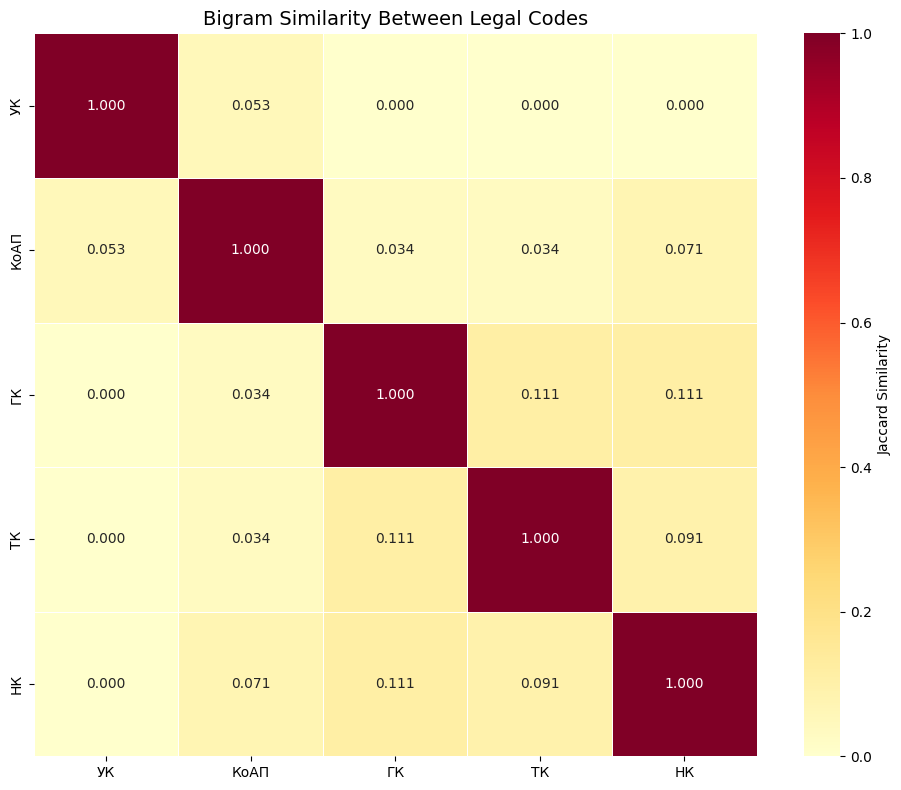


Bigram Similarity Matrix:


,УК,КоАП,ГК,ТК,НК
УК,1.000,0.053,0.000,0.000,0.000
КоАП,0.053,1.000,0.034,0.034,0.071
ГК,0.000,0.034,1.000,0.111,0.111
ТК,0.000,0.034,0.111,1.000,0.091
НК,0.000,0.071,0.111,0.091,1.000


In [24]:
# Calculate Jaccard similarity based on top bigrams
code_keys = list(CODES.keys())
n = len(code_keys)
similarity_matrix = np.zeros((n, n))

for i, k1 in enumerate(code_keys):
    set1 = set(phrase for phrase, _ in bigrams[k1])
    for j, k2 in enumerate(code_keys):
        set2 = set(phrase for phrase, _ in bigrams[k2])
        jaccard = len(set1 & set2) / len(set1 | set2) if len(set1 | set2) > 0 else 0
        similarity_matrix[i, j] = jaccard

code_labels = [CODES[k]["short"] for k in code_keys]
sim_df = pd.DataFrame(similarity_matrix, index=code_labels, columns=code_labels)

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Jaccard Similarity"}
)
plt.title("Bigram Similarity Between Legal Codes", fontsize=14)
plt.tight_layout()
plt.savefig("../output/05/bigram_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nBigram Similarity Matrix:")
sim_df.round(3)

## 8. Summary and Export

In [26]:
# Load version information
version_info = {}
for code_key in CODES:
    folder_path = DATA_PATH / CODES[code_key]["history_folder"]
    index_path = folder_path / "versions_index.json"
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    latest = index["versions"][-1]
    version_info[code_key] = {
        "version_number": latest["version_number"],
        "version_date": latest["version_date"]
    }

print("="*70)
print("KEY FINDINGS - N-gram and Collocation Analysis")
print("="*70)

print("\n" + "="*70)
print("1. N-GRAM EXTRACTION OVERVIEW")
print("="*70)

# Calculate totals
total_bigrams = sum(len(bg) for bg in bigrams.values())
total_trigrams = sum(len(tg) for tg in trigrams.values())
all_bigram_phrases = set()
for bg in bigrams.values():
    all_bigram_phrases.update(phrase for phrase, _ in bg)

total_docs = sum(len(docs) for docs in preprocessed_docs.values())

print(f"""
   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version {version_info['criminal']['version_number']} ({version_info['criminal']['version_date']})
   • Administrative Code (КоАП): version {version_info['administrative']['version_number']} ({version_info['administrative']['version_date']})
   • Civil Code (ГК): version {version_info['civil']['version_number']} ({version_info['civil']['version_date']})
   • Labor Code (ТК): version {version_info['labor']['version_number']} ({version_info['labor']['version_date']})
   • Tax Code (НК): version {version_info['tax']['version_number']} ({version_info['tax']['version_date']})
   
   CORPUS STATISTICS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК):        {len(preprocessed_docs['criminal']):,} documents processed
   • Administrative Code (КоАП): {len(preprocessed_docs['administrative']):,} documents processed
   • Civil Code (ГК):           {len(preprocessed_docs['civil']):,} documents processed
   • Labor Code (ТК):           {len(preprocessed_docs['labor']):,} documents processed
   • Tax Code (НК):             {len(preprocessed_docs['tax']):,} documents processed
   
   TOTAL: {total_docs:,} legal articles analyzed
   
   EXTRACTION PARAMETERS:
   ─────────────────────────────────────────────────────────────────────
   • Bigrams per code:          30 (top by frequency)
   • Trigrams per code:         20 (top by frequency)
   • Min document frequency:    2 (appear in 2+ articles)
   • Max vocabulary:            1,000 terms
   • Preprocessing:             Lemmatization via spaCy
   
   EXTRACTION RESULTS:
   ─────────────────────────────────────────────────────────────────────
   • Total bigram entries:      {total_bigrams}
   • Total trigram entries:     {total_trigrams}
   • Unique bigram phrases:     {len(all_bigram_phrases)}
""")

print("="*70)
print("2. TOP BIGRAMS BY CODE")
print("="*70)

for code_key in CODES:
    short = CODES[code_key]['short']
    name = CODES[code_key]['name_en']
    bg = bigrams[code_key][:5]
    print(f"\n   {name} ({short}):")
    print("   " + "─"*67)
    for i, (phrase, freq) in enumerate(bg, 1):
        print(f"   {i}. {phrase:<35} {int(freq):,} occurrences")

print("\n" + "="*70)
print("3. TOP TRIGRAMS BY CODE")
print("="*70)

for code_key in CODES:
    short = CODES[code_key]['short']
    name = CODES[code_key]['name_en']
    tg = trigrams[code_key][:4]
    print(f"\n   {name} ({short}):")
    print("   " + "─"*67)
    for phrase, freq in tg:
        print(f"   • {phrase:<40} {int(freq):,}")

print("\n" + "="*70)
print("4. SHARED LEGAL PHRASES")
print("="*70)

# Recalculate shared bigrams
shared_bigrams = {k: v for k, v in bigram_to_codes.items() if len(v) >= 3}

print(f"""
   BIGRAMS IN 3+ CODES ({len(shared_bigrams)} phrases):
   ─────────────────────────────────────────────────────────────────────""")

for phrase, codes_list in sorted(shared_bigrams.items(), key=lambda x: sum(f for _, f in x[1]), reverse=True):
    code_str = " | ".join([f"{c}: {int(f):,}" for c, f in codes_list])
    print(f"\n   • {phrase}")
    print(f"     └─ {code_str}")

print(f"""
   
   KEY INSIGHT: Shared phrases are primarily:
   • Jurisdictional markers (республика казахстан)
   • Internal references (настоящий кодекс, статья)
   • Subject definitions (юридический лицо)
   
   Note: Criminal Code (УК) shares NO top bigrams with other codes,
   reflecting its distinct penalty-focused vocabulary.
""")

print("="*70)
print("5. UNIQUE PHRASES PER CODE")
print("="*70)

for code_key in CODES:
    short = CODES[code_key]['short']
    name = CODES[code_key]['name_en']
    unique_count = len(unique_bigrams[code_key])
    
    # Get top unique with frequency
    unique_with_freq = [(p, f) for p, f in bigrams[code_key] if p in unique_bigrams[code_key]][:5]
    
    print(f"\n   {name} ({short}) - {unique_count} Unique Bigrams:")
    print("   " + "─"*67)
    for phrase, freq in unique_with_freq:
        print(f"   • {phrase:<30} ({int(freq):,})")

print("\n" + "="*70)
print("6. BIGRAM SIMILARITY ANALYSIS")
print("="*70)

# Calculate similarity stats
sim_matrix_copy = similarity_matrix.copy()
np.fill_diagonal(sim_matrix_copy, 0)
max_idx = np.unravel_index(sim_matrix_copy.argmax(), sim_matrix_copy.shape)
most_similar = (code_labels[max_idx[0]], code_labels[max_idx[1]])
max_sim = sim_matrix_copy.max()

min_val = sim_matrix_copy[sim_matrix_copy > 0].min() if (sim_matrix_copy > 0).any() else 0
min_idx = np.where(sim_matrix_copy == min_val)
least_similar = (code_labels[min_idx[0][0]], code_labels[min_idx[1][0]])

print(f"""
   JACCARD SIMILARITY MATRIX (based on top 30 bigrams):
   ─────────────────────────────────────────────────────────────────────""")

# Print matrix
header = "         " + "".join([f"{lbl:<8}" for lbl in code_labels])
print(header)
for i, label in enumerate(code_labels):
    row = f"   {label:<6}"
    for j in range(len(code_labels)):
        if i == j:
            row += "-       "
        else:
            row += f"{similarity_matrix[i,j]:.3f}   "
    print(row)

print(f"""
   
   KEY FINDINGS:
   ─────────────────────────────────────────────────────────────────────
   Most Similar:   {most_similar[0]} & {most_similar[1]} (Jaccard: {max_sim:.3f})
   Least Similar:  {least_similar[0]} & {least_similar[1]} (Jaccard: {min_val:.3f})
   
   INTERPRETATION:
   • Criminal Code (УК) is MOST ISOLATED - shares almost no phrases
     with other codes (minimal overlap)
   • Civil & Labor codes most similar ({max_sim:.1%}) - both deal with
     contracts, rights, and party relationships
   • Administrative Code bridges criminal and civil domains
   • Tax Code moderately connected to civil/labor (business context)
""")

print("="*70)
print("7. LEGAL TERMINOLOGY PATTERNS")
print("="*70)

for pattern_name, keywords in legal_patterns.items():
    print(f"\n   {pattern_name.upper()} ({', '.join(keywords)}):")
    print("   " + "─"*67)
    print(f"   {'Code':<6}| {'Top Phrase':<32}| Frequency")
    print("   " + "──────┼" + "─"*33 + "┼" + "─"*10)
    
    for code_key in CODES:
        matching = []
        for phrase, freq in bigrams[code_key]:
            if any(kw in phrase for kw in keywords):
                matching.append((phrase, freq))
        
        if matching:
            top_match = matching[0]
            print(f"   {CODES[code_key]['short']:<6}| {top_match[0]:<32}| {int(top_match[1]):,}")

print("\n" + "="*70)
print("8. FREQUENCY DISTRIBUTION INSIGHTS")
print("="*70)

# Find highest frequency bigrams across all codes
all_bigrams_flat = []
for code_key in CODES:
    for phrase, freq in bigrams[code_key]:
        all_bigrams_flat.append((phrase, CODES[code_key]['short'], int(freq)))

all_bigrams_flat.sort(key=lambda x: x[2], reverse=True)

print("""
   HIGHEST FREQUENCY BIGRAMS (across all codes):
   ─────────────────────────────────────────────────────────────────────
   Rank | Phrase                       | Code  | Frequency
   ─────┼──────────────────────────────┼───────┼───────────""")

for rank, (phrase, code, freq) in enumerate(all_bigrams_flat[:8], 1):
    print(f"   {rank:<4} | {phrase:<28} | {code:<5} | {freq:,}")

print(f"""
   
   FREQUENCY RANGES BY CODE:
   ─────────────────────────────────────────────────────────────────────""")

for code_key in CODES:
    short = CODES[code_key]['short']
    freqs = [int(f) for _, f in bigrams[code_key]]
    if freqs:
        min_f, max_f = min(freqs), max(freqs)
        ratio = max_f / min_f if min_f > 0 else 0
        print(f"   {short}:   {min_f:,} - {max_f:,}  ({ratio:.0f}x range)")

print("\n" + "="*70)
print("9. KEY INSIGHTS FOR LEGAL AI/NLP")
print("="*70)
print(f"""
   STRUCTURAL PATTERNS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code uses unique phrasing despite conceptual overlap
   • Administrative Code has most repetitive structure (fines by subject)
   • Civil/Labor codes share relationship-based terminology
   • Tax Code heavily self-referential (статья настоящий кодекс)
   
   APPLICATIONS:
   ─────────────────────────────────────────────────────────────────────
   • Code Classification: Unique bigrams serve as strong features
   • Information Extraction: Domain collocations improve NER
   • Legal Search: Phrase-level indexing captures multi-word terms
   • Machine Translation: Collocations require unified translation
   
   CROSS-CODE PATTERNS:
   ─────────────────────────────────────────────────────────────────────
   • Universal: республика казахстан, настоящий кодекс
   • Punitive: лишение свободы (УК), влечь штраф (КоАП)
   • Contractual: трудовой договор (ТК), право собственность (ГК)
   • Fiscal: налог на, налоговый период (НК)
   
   METHODOLOGICAL NOTES:
   ─────────────────────────────────────────────────────────────────────
   • Lemmatization normalizes Russian morphology
   • Stopword removal may affect legal phrases (e.g., "в размере")
   • Frequency thresholds filter noise but may miss rare terms
   • Jaccard similarity sensitive to vocabulary size
""")

print("="*70)

KEY FINDINGS - N-gram and Collocation Analysis

1. N-GRAM EXTRACTION OVERVIEW

   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version 109 (16.09.2025)
   • Administrative Code (КоАП): version 205 (17.12.2025)
   • Civil Code (ГК): version 179 (20.11.2025)
   • Labor Code (ТК): version 69 (16.09.2025)
   • Tax Code (НК): version 1 (18.07.2025)

   CORPUS STATISTICS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК):        489 documents processed
   • Administrative Code (КоАП): 1,009 documents processed
   • Civil Code (ГК):           415 documents processed
   • Labor Code (ТК):           218 documents processed
   • Tax Code (НК):             847 documents processed

   TOTAL: 2,978 legal articles analyzed

   EXTRACTION PARAMETERS:
   ─────────────────────────────────────────────────────────────────────
   • Bigrams per code:          30 (top by frequency)
   • Trigram

In [27]:
# Export results
bigram_export = []
for code_key in CODES:
    for phrase, freq in bigrams[code_key]:
        bigram_export.append({
            "code": CODES[code_key]["short"],
            "bigram": phrase,
            "frequency": int(freq)
        })

pd.DataFrame(bigram_export).to_csv("../output/05/bigrams.csv", index=False)
sim_df.to_csv("../output/05/bigram_similarity.csv")

print("Exported to output/05/:")
print("  - bigrams.csv")
print("  - bigram_similarity.csv")

Exported to output/05/:
  - bigrams.csv
  - bigram_similarity.csv
